In [1]:
import pandas as pd
import numpy as np

In [2]:
BASE = "dados/employee_attrition.csv"

df = pd.read_csv(BASE)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
with pd.option_context("float_format", "{:.2f}".format, "display.max_columns", 35):
    display(df.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [4]:
df.describe(exclude="number")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


EXERCICIOS 

- remover colunas com valores unicos 
- encontrar os registros dos 10 funcionarios mais velhos e dos 10 mais novos
- encontrar os regristros dos 10 funcionarios com mais tempos de empresa e os 10 com menos tempo
- encontrar os registros dos 10 funcionarios com mais tempo no cargo (sem promoção) e com menos tempo

----------------------------------------------------------------------------------------------------------

- agrupamentos (em cada caso mostrar também o agrupamento por saida ou não do funcionario)

- contagem de funcionarios por departamento 
- genero por departamento
- genero por cargo 
- media de salário por cargo 
- média de salario por cargo e nivel 
- contagem de genero por departamento 
- media de salario por nivel educacional

In [5]:
df.shape

(1470, 35)

In [6]:
df["EmployeeNumber"].nunique()

1470

- remover colunas com valores unicos 

In [7]:
df = df.drop(["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

- encontrar os registros dos 10 funcionarios mais velhos e dos 10 mais novos


In [9]:
df.nlargest(10, "Age")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
411,60,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,1,Female,...,3,4,0,33,5,1,29,8,11,10
427,60,No,Travel_Frequently,1499,Sales,28,3,Marketing,3,Female,...,3,4,0,22,5,4,18,13,13,11
536,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,Male,...,3,4,0,10,1,3,2,2,2,2
879,60,No,Travel_Rarely,696,Sales,7,4,Marketing,2,Male,...,3,2,1,12,3,3,11,7,1,9
1209,60,No,Travel_Rarely,370,Research & Development,1,4,Medical,3,Male,...,4,3,1,19,2,4,1,0,0,0
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
63,59,No,Travel_Rarely,1435,Sales,25,3,Life Sciences,1,Female,...,3,4,0,28,3,2,21,16,7,9
70,59,No,Travel_Frequently,1225,Sales,1,1,Life Sciences,1,Female,...,3,4,0,20,2,2,4,3,1,3
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,3,Female,...,4,4,1,30,3,3,3,2,2,2
225,59,No,Travel_Rarely,142,Research & Development,3,3,Life Sciences,3,Male,...,3,1,1,7,6,3,1,0,0,0


In [10]:
df.nsmallest(10, "Age")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
296,18,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,3,Male,...,3,3,0,0,2,3,0,0,0,0
301,18,No,Travel_Rarely,812,Sales,10,3,Medical,4,Female,...,3,1,0,0,2,3,0,0,0,0
457,18,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,2,Male,...,3,4,0,0,3,3,0,0,0,0
727,18,No,Non-Travel,287,Research & Development,5,2,Life Sciences,2,Male,...,3,4,0,0,2,3,0,0,0,0
828,18,Yes,Non-Travel,247,Research & Development,8,1,Medical,3,Male,...,3,4,0,0,0,3,0,0,0,0
972,18,No,Non-Travel,1124,Research & Development,1,3,Life Sciences,4,Female,...,3,3,0,0,5,4,0,0,0,0
1153,18,Yes,Travel_Frequently,544,Sales,3,2,Medical,2,Female,...,3,3,0,0,2,4,0,0,0,0
1311,18,No,Non-Travel,1431,Research & Development,14,3,Medical,2,Female,...,3,3,0,0,4,1,0,0,0,0
127,19,Yes,Travel_Rarely,528,Sales,22,1,Marketing,4,Male,...,3,4,0,0,2,2,0,0,0,0
149,19,No,Travel_Rarely,1181,Research & Development,3,1,Medical,2,Female,...,3,4,0,1,3,3,1,0,0,0


- encontrar os regristros dos 10 funcionarios com mais tempos de empresa e os 10 com menos tempo


In [11]:
df.nlargest(10, "YearsAtCompany")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
126,58,Yes,Travel_Rarely,147,Research & Development,23,4,Medical,4,Female,...,3,4,1,40,3,2,40,10,15,6
98,58,No,Travel_Rarely,682,Sales,10,4,Medical,4,Male,...,3,3,0,38,1,2,37,10,1,8
270,55,No,Travel_Rarely,452,Research & Development,1,3,Medical,4,Male,...,3,3,0,37,2,3,36,10,4,13
1116,55,No,Travel_Rarely,685,Sales,26,5,Marketing,3,Male,...,4,3,1,36,3,3,36,6,2,13
561,52,No,Travel_Rarely,621,Sales,3,4,Marketing,3,Male,...,3,1,0,34,3,4,34,6,1,16
190,52,No,Travel_Rarely,699,Research & Development,1,4,Life Sciences,3,Male,...,3,1,1,34,5,3,33,18,11,9
237,52,No,Non-Travel,771,Sales,2,4,Life Sciences,1,Male,...,3,4,0,33,2,4,33,7,15,12
914,55,No,Non-Travel,177,Research & Development,8,1,Medical,4,Male,...,3,4,1,34,3,3,33,9,15,0
962,51,No,Travel_Rarely,770,Human Resources,5,3,Life Sciences,3,Male,...,3,2,1,33,2,3,33,9,0,10
1111,53,Yes,Travel_Rarely,607,Research & Development,2,5,Technical Degree,3,Female,...,3,2,1,34,4,3,33,7,1,9


In [12]:
df.nsmallest(10, "YearsAtCompany")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
23,21,No,Travel_Rarely,391,Research & Development,15,2,Life Sciences,3,Male,...,3,4,0,0,6,3,0,0,0,0
77,45,No,Travel_Rarely,193,Research & Development,6,4,Other,4,Male,...,3,2,0,17,3,4,0,0,0,0
86,23,No,Travel_Rarely,541,Sales,2,1,Technical Degree,3,Male,...,3,3,1,3,3,3,0,0,0,0
109,22,No,Travel_Rarely,534,Research & Development,15,3,Medical,2,Female,...,3,3,0,1,5,3,0,0,0,0
127,19,Yes,Travel_Rarely,528,Sales,22,1,Marketing,4,Male,...,3,4,0,0,2,2,0,0,0,0
171,19,Yes,Travel_Frequently,602,Sales,1,1,Technical Degree,3,Female,...,4,1,0,1,5,4,0,0,0,0
264,28,Yes,Travel_Rarely,529,Research & Development,2,4,Life Sciences,1,Male,...,3,3,0,5,5,1,0,0,0,0
265,29,No,Travel_Rarely,1210,Sales,2,3,Medical,1,Male,...,3,2,2,10,2,3,0,0,0,0
296,18,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,3,Male,...,3,3,0,0,2,3,0,0,0,0


- encontrar os registros dos 10 funcionarios com mais tempo no cargo (sem promoção) e com menos tempo


In [13]:
df.nlargest(10, "YearsSinceLastPromotion")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,...,3,4,0,23,0,3,22,15,15,8
123,51,No,Travel_Rarely,684,Research & Development,6,3,Life Sciences,1,Male,...,3,3,0,23,5,3,20,18,15,15
126,58,Yes,Travel_Rarely,147,Research & Development,23,4,Medical,4,Female,...,3,4,1,40,3,2,40,10,15,6
178,46,No,Travel_Rarely,526,Sales,1,2,Marketing,2,Female,...,4,3,3,24,2,3,24,13,15,7
237,52,No,Non-Travel,771,Sales,2,4,Life Sciences,1,Male,...,3,4,0,33,2,4,33,7,15,12
425,50,No,Travel_Rarely,1099,Research & Development,29,4,Life Sciences,2,Male,...,3,2,1,28,2,3,27,10,15,7
701,53,No,Travel_Rarely,1376,Sales,2,2,Medical,3,Male,...,3,3,1,22,3,4,17,13,15,2
752,36,Yes,Travel_Rarely,885,Research & Development,16,4,Life Sciences,3,Female,...,3,3,0,18,1,3,17,13,15,14
861,46,No,Travel_Rarely,1402,Sales,2,3,Marketing,3,Female,...,4,1,0,28,2,3,26,15,15,9
914,55,No,Non-Travel,177,Research & Development,8,1,Medical,4,Male,...,3,4,1,34,3,3,33,9,15,0


In [14]:
df.nsmallest(10, "YearsSinceLastPromotion")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
10,35,No,Travel_Rarely,809,Research & Development,16,3,Medical,1,Male,...,3,3,1,6,5,3,5,4,0,3
11,29,No,Travel_Rarely,153,Research & Development,15,2,Life Sciences,4,Female,...,3,4,0,10,3,3,9,5,0,8
14,28,Yes,Travel_Rarely,103,Research & Development,24,3,Life Sciences,3,Male,...,3,2,0,6,4,3,4,2,0,3
16,32,No,Travel_Rarely,334,Research & Development,5,2,Life Sciences,1,Male,...,3,4,2,7,5,2,6,2,0,5
17,22,No,Non-Travel,1123,Research & Development,16,2,Medical,4,Male,...,3,2,2,1,2,2,1,0,0,0
21,36,Yes,Travel_Rarely,1218,Sales,9,4,Life Sciences,3,Male,...,4,2,0,10,4,3,5,3,0,3


In [15]:
df.nlargest(10, "YearsSinceLastPromotion")[["Age", "JobRole", "YearsSinceLastPromotion", "JobLevel", "Attrition"]]

,Age,JobRole,YearsSinceLastPromotion,JobLevel,Attrition
45,41,Research Director,15,5,Yes
123,51,Research Director,15,5,No
126,58,Healthcare Representative,15,3,Yes
178,46,Sales Executive,15,3,No
237,52,Manager,15,5,No
425,50,Manager,15,4,No
701,53,Manager,15,4,No
752,36,Laboratory Technician,15,1,Yes
861,46,Manager,15,4,No
914,55,Healthcare Representative,15,4,No


In [16]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [17]:
colunas_categoricas_nao_ordenadas = [
    "BusinessTravel", 
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

colunas_categoricas_ordenadas = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

coluna_alvo = ["Attrition"]

colunas_numericas = [
    coluna for coluna in df.columns if coluna not in (
        colunas_categoricas_nao_ordenadas + colunas_categoricas_ordenadas + coluna_alvo
    )
]

In [18]:
colunas_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [19]:
for coluna in (colunas_categoricas_nao_ordenadas + colunas_categoricas_ordenadas):
    print(f"{coluna}: {df[coluna].unique()}")

BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: ['Female' 'Male']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: ['Single' 'Married' 'Divorced']
OverTime: ['Yes' 'No']
Education: [2 1 4 3 5]
EnvironmentSatisfaction: [2 3 4 1]
JobInvolvement: [3 2 4 1]
JobLevel: [2 1 3 4 5]
JobSatisfaction: [4 2 3 1]
PerformanceRating: [3 4]
RelationshipSatisfaction: [1 4 2 3]
StockOptionLevel: [0 1 3 2]
WorkLifeBalance: [1 3 2 4]


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [21]:
for coluna in colunas_categoricas_nao_ordenadas:
    df[coluna] = df[coluna].astype("category")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   object  
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   category
 8   EnvironmentSatisfaction   1470 non-null   int64   
 9   Gender                    1470 non-null   category
 10  HourlyRate                1470 non-null   int64   
 11  JobInvolvement            1470 non-null   int64   
 12  JobLevel                  1470 non-null   int64   
 13  JobRole                   1470 non-null   catego

In [25]:
for coluna in df.select_dtypes(include="category"):
    print(f"{coluna}")
    print(f"{coluna}.cat.categories: {df[coluna].cat.categories}")
    print(f"{coluna}.cat.ordered: {df[coluna].cat.ordered}")
    print(f"{coluna}.cat.codes: {df[coluna].cat.codes.unique()}")
    print()  # Reducção de memoria


BusinessTravel
BusinessTravel.cat.categories: Index(['Non-Travel', 'Travel_Frequently', 'Travel_Rarely'], dtype='object')
BusinessTravel.cat.ordered: False
BusinessTravel.cat.codes: [2 1 0]

Department
Department.cat.categories: Index(['Human Resources', 'Research & Development', 'Sales'], dtype='object')
Department.cat.ordered: False
Department.cat.codes: [2 1 0]

EducationField
EducationField.cat.categories: Index(['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other',
       'Technical Degree'],
      dtype='object')
EducationField.cat.ordered: False
EducationField.cat.codes: [1 4 3 2 5 0]

Gender
Gender.cat.categories: Index(['Female', 'Male'], dtype='object')
Gender.cat.ordered: False
Gender.cat.codes: [0 1]

JobRole
JobRole.cat.categories: Index(['Healthcare Representative', 'Human Resources', 'Laboratory Technician',
       'Manager', 'Manufacturing Director', 'Research Director',
       'Research Scientist', 'Sales Executive', 'Sales Representative'],
      dtype=

<Axes: xlabel='Attrition'>

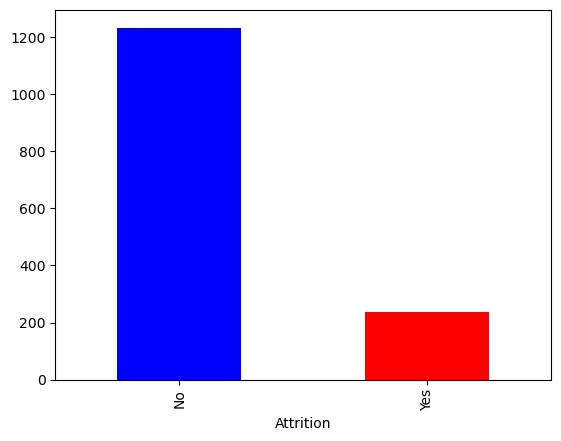

In [32]:
df["Attrition"].value_counts().plot(kind="bar", color=["blue", "red"])

<Axes: xlabel='Attrition'>

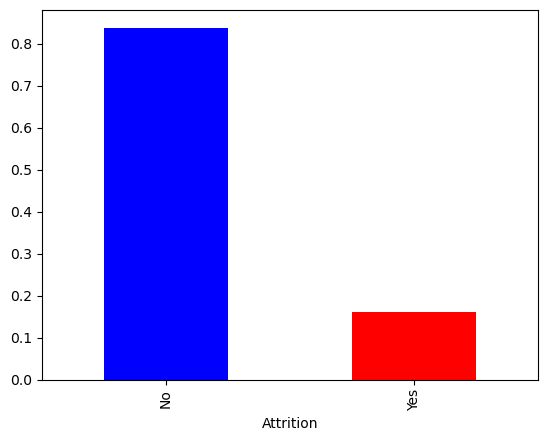

In [33]:
df["Attrition"].value_counts(normalize=True).plot(kind="bar", color=["blue", "red"])

<Axes: xlabel='Department'>

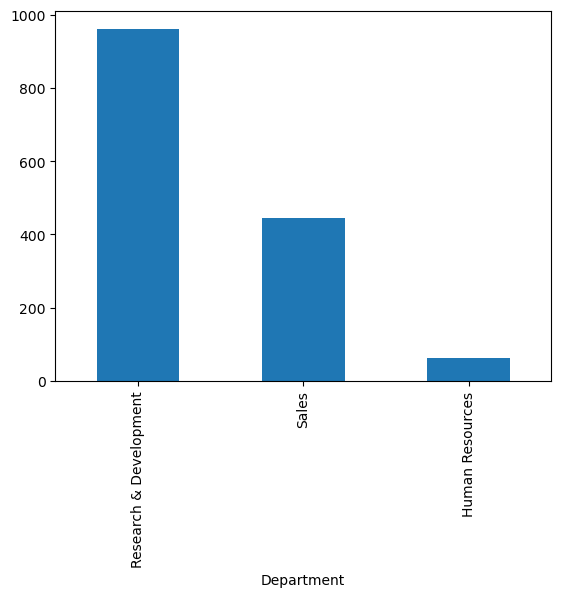

In [36]:
df["Department"].value_counts().plot(kind="bar")

In [38]:
df.groupby(["Department", "Attrition"]).size()

/tmp/ipykernel_118886/3423689319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Department", "Attrition"]).size()


Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
dtype: int64

In [39]:
df.pivot_table(index="Department", columns="Attrition", aggfunc="size")

/tmp/ipykernel_118886/3522836018.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="Department", columns="Attrition", aggfunc="size")


Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


A função crosstab() do Pandas é uma ferramenta poderosa para criar tabelas de contingência, que são usadas para mostrar a relação entre duas ou mais variáveis categóricas. Basicamente, a tabela resultante oferece uma visão clara de como as categorias de uma variável estão distribuídas em relação a outra variável.


In [42]:
pd.crosstab(df["Department"], df["Attrition"], normalize="index")

Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


In [ ]:
pd.crosstab(df["Department"], df["Attrition"], normalize="columns")

Attrition,No,Yes
Department,,
Human Resources,0.041363,0.050633
Research & Development,0.671533,0.561181
Sales,0.287105,0.388186


In [47]:
pd.crosstab(df["Department"], df["Attrition"], normalize="index").style.background_gradient(cmap="RdYlGn", axis="columns")

Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


In [50]:
pd.crosstab(df["Department"], df["Attrition"], margins=True, margins_name="Total")

Attrition,No,Yes,Total
Department,,,
Human Resources,51,12,63
Research & Development,828,133,961
Sales,354,92,446
Total,1233,237,1470


<Axes: xlabel='Department'>

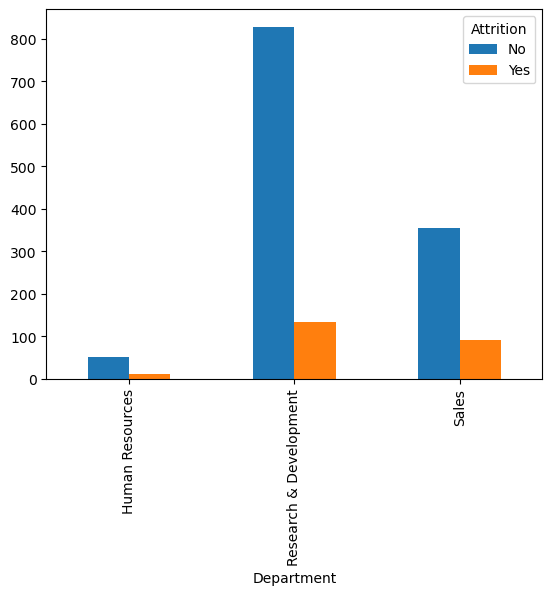

In [51]:
pd.crosstab(df["Department"], df["Attrition"]).plot(kind="bar")